In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Load cleaned data
nav  = pd.read_csv('data/processed/clean_nav.csv', parse_dates=['date'])
perf = pd.read_csv('data/processed/clean_schema_performance.csv')
fund = pd.read_csv('data/raw/01_fund_master.csv')
bench = pd.read_csv('data/raw/10_benchmark_indices.csv', parse_dates=['date'])

# Sanity checks
print("NAV shape      :", nav.shape)
print("Date range     :", nav['date'].min(), "->", nav['date'].max())
print("Unique funds   :", nav['amfi_code'].nunique())
print("Benchmark cols :", bench.columns.tolist())

# Sort before any calculations
nav.sort_values(['amfi_code','date'], inplace=True)

NAV shape      : (46000, 4)
Date range     : 2022-01-03 00:00:00 -> 2026-05-29 00:00:00
Unique funds   : 40
Benchmark cols : ['date', 'index_name', 'close_value']


## **Computing Daily Returns for All 40 Funds**

### **Formula**

**Daily Return = (NAVₜ / NAVₜ₋₁) − 1**

In [7]:
nav.sort_values(['amfi_code', 'date'], inplace=True)

# Daily return per fund — grouped so fund boundaries don't bleed
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Drop the first NaN row of each fund
nav.dropna(subset=['daily_return'], inplace=True)

# Sanity check — returns should mostly be between -10% and +10%
print("Return stats:\n", nav['daily_return'].describe())
print("\nOutliers (|return| > 15%):", (nav['daily_return'].abs() > 0.15).sum())

nav.to_csv('../data/processed/returns_computed.csv', index=False)
print("\n✓ Saved returns_computed.csv")

Return stats:
 count    45920.000000
mean         0.000633
std          0.010290
min         -0.058102
25%         -0.005040
50%          0.000341
75%          0.006325
max          0.064713
Name: daily_return, dtype: float64

Outliers (|return| > 15%): 0

✓ Saved returns_computed.csv


## **Compute CAGR for 1yr, 3yr, 5yr periods**
## **Formula**
**CAGR = (NAV_end / NAV_start) ^ (1 / n_years) – 1**

In [8]:
def cagr(nav_end, nav_start, n_trading_days):
    """CAGR using trading-day count."""
    if nav_start <= 0 or n_trading_days <= 0:
        return np.nan
    years = n_trading_days / 252
    return (nav_end / nav_start) ** (1 / years) - 1

results = []

for code, grp in nav.groupby('amfi_code'):
    grp = grp.sort_values('date').reset_index(drop=True)
    latest_nav = grp['nav'].iloc[-1]
    n_total    = len(grp)
    row = {'amfi_code': code}

    if n_total >= 252:          # 1yr
        row['cagr_1yr'] = cagr(latest_nav, grp['nav'].iloc[-252], 252)
    if n_total >= 756:          # 3yr
        row['cagr_3yr'] = cagr(latest_nav, grp['nav'].iloc[-756], 756)
    if n_total >= 1260:         # 5yr
        row['cagr_5yr'] = cagr(latest_nav, grp['nav'].iloc[-1260], 1260)

    results.append(row)
cagr_df = pd.DataFrame(results)
# Keep as decimal (0.1245 = 12.45%) — convert to % only when displaying
cagr_df.to_csv('../data/processed/cagr_report.csv', index=False)

print("Top 10 by 3yr CAGR:\n")
top = cagr_df.sort_values('cagr_3yr', ascending=False).head(10)
top['cagr_3yr_pct'] = (top['cagr_3yr'] * 100).round(2)
print(top[['amfi_code','cagr_3yr_pct']].to_string(index=False))

Top 10 by 3yr CAGR:

 amfi_code  cagr_3yr_pct
    119094         36.07
    100033         33.63
    101206         32.53
    148567         31.28
    120505         30.21
    120504         28.37
    119598         27.81
    119551         27.73
    102887         25.66
    120843         25.66


## **Computing Sharp Ratio for every fund**
## **Formula**
**Sharpe = (Rp – Rf) / σp × √252**

In [9]:
RISK_FREE_ANNUAL = 0.065
Rf_daily = RISK_FREE_ANNUAL / 252   # daily risk-free rate

sharpe_rows = []

for code, grp in nav.groupby('amfi_code'):
    returns = grp['daily_return'].dropna()
    if len(returns) < 60:
        continue
    mean_r = returns.mean()
    std_r  = returns.std()
    if std_r == 0:
        continue
    sharpe = (mean_r - Rf_daily) / std_r * np.sqrt(252)
    sharpe_rows.append({'amfi_code': code, 'sharpe_ratio': round(sharpe, 4)})

sharpe_df = pd.DataFrame(sharpe_rows)
sharpe_df.to_csv('../data/processed/sharpe_values.csv', index=False)

print("Top 10 by Sharpe Ratio:\n")
print(sharpe_df.sort_values('sharpe_ratio', ascending=False)
      .head(10).to_string(index=False))

Top 10 by Sharpe Ratio:

 amfi_code  sharpe_ratio
    148567        1.4220
    120843        1.2842
    148569        1.2256
    119551        1.2103
    120505        1.2051
    149323        1.1323
    100033        1.1106
    118632        1.0837
    120504        1.0457
    101206        1.0263


## ** Computing Sortino Ratio**
## **Formula**
**Sortino = (Rp – Rf) / Downside_σ × √252**

In [10]:
sortino_rows = []

for code, grp in nav.groupby('amfi_code'):
    returns = grp['daily_return'].dropna()
    if len(returns) < 60:
        continue
    mean_r = returns.mean()

    negative_returns = returns[returns < 0]
    if len(negative_returns) < 5:
        continue
    downside_std = negative_returns.std()
    if downside_std == 0:
        continue

    sortino = (mean_r - Rf_daily) / downside_std * np.sqrt(252)
    sortino_rows.append({'amfi_code': code, 'sortino_ratio': round(sortino, 4)})

sortino_df = pd.DataFrame(sortino_rows)
sortino_df.to_csv('../data/processed/sortino_values.csv', index=False)

# Compare side by side
comparison = sharpe_df.merge(sortino_df, on='amfi_code')
print("Sharpe vs Sortino (top 10 by Sortino):\n")
print(comparison.sort_values('sortino_ratio', ascending=False)
      .head(10).to_string(index=False))


Sharpe vs Sortino (top 10 by Sortino):

 amfi_code  sharpe_ratio  sortino_ratio
    148567        1.4220         2.3392
    120843        1.2842         2.3216
    119551        1.2103         2.1459
    148569        1.2256         2.1313
    120505        1.2051         2.0731
    149323        1.1323         1.8763
    100033        1.1106         1.8560
    118632        1.0837         1.8550
    120504        1.0457         1.8379
    101206        1.0263         1.7988


## **Computing Alpha&Beta (OLS regression vs benchmark)**
## **Formula**
**Rp = α + β × Rm → Beta = slope, Alpha = intercept × 252**

In [16]:
# prepare benchmark returns
print(bench.columns.tolist())

# Adjust 'nifty_100' below to match your actual column name
bench_nifty = bench[bench['index_name'] == 'NIFTY100'].copy()

bench_nifty.sort_values('date', inplace=True)
bench_nifty['nifty100_return'] = bench_nifty['close_value'].pct_change()
bench_ret = bench_nifty[['date', 'nifty100_return']].dropna()
print("Benchmark rows:", len(bench_ret))

['date', 'index_name', 'close_value']
Benchmark rows: 1149


In [17]:
#OLS regression per fund
from scipy.stats import linregress

alpha_beta_rows = []

for code, grp in nav.groupby('amfi_code'):
    fund_ret = grp[['date','daily_return']].dropna()
    merged = fund_ret.merge(bench_ret, on='date', how='inner')
    if len(merged) < 60:
        continue

    x = merged['nifty100_return'].values   # market (independent)
    y = merged['daily_return'].values       # fund (dependent)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    alpha_beta_rows.append({
        'amfi_code' : code,
        'beta'      : round(slope, 4),
        'alpha'     : round(intercept * 252, 4),   # annualised
        'r_squared' : round(r_value**2, 4)
    })

ab_df = pd.DataFrame(alpha_beta_rows)
ab_df.to_csv('../data/processed/alpha_beta.csv', index=False)
print("Highest Alpha funds:\n")
print(ab_df.sort_values('alpha', ascending=False).head(10).to_string(index=False))

Highest Alpha funds:

 amfi_code    beta  alpha  r_squared
    119598 -0.0261 0.3070     0.0002
    149324  0.0094 0.3032     0.0000
    120505 -0.0033 0.2974     0.0000
    148569  0.0195 0.2810     0.0002
    100033  0.0025 0.2752     0.0000
    120843 -0.0198 0.2695     0.0003
    149323 -0.0026 0.2661     0.0000
    148567  0.0270 0.2656     0.0006
    119094 -0.0673 0.2620     0.0020
    119551 -0.0321 0.2325     0.0009


## **Computing Maximum Drawdown per fund**
## **Formula**
**Max Drawdown = min(NAV / cummax(NAV) – 1)**

In [18]:
drawdown_rows = []

for code, grp in nav.groupby('amfi_code'):
    grp = grp.sort_values('date').reset_index(drop=True)
    nav_series  = grp['nav']
    running_max = nav_series.cummax()          # peak seen so far
    drawdown    = (nav_series / running_max) - 1  # drawdown at each point
    max_dd      = drawdown.min()               # worst (most negative) value
    worst_idx   = drawdown.idxmin()
    worst_date  = grp['date'].iloc[worst_idx].strftime('%Y-%m-%d')

    drawdown_rows.append({
        'amfi_code'          : code,
        'max_drawdown_pct'   : round(max_dd * 100, 2),
        'worst_drawdown_date': worst_date
    })

mdd_df = pd.DataFrame(drawdown_rows)
mdd_df.to_csv('../data/processed/max_drawdown.csv', index=False)

print("Worst drawdowns:\n")
print(mdd_df.sort_values('max_drawdown_pct').head(10).to_string(index=False))

Worst drawdowns:

 amfi_code  max_drawdown_pct worst_drawdown_date
    119599            -52.57          2025-10-28
    119095            -51.68          2026-05-11
    101207            -35.45          2026-05-11
    149324            -31.17          2025-01-03
    119598            -28.71          2025-05-14
    102886            -28.00          2026-04-27
    100016            -24.73          2022-09-15
    120842            -24.00          2024-10-17
    118634            -23.34          2026-02-20
    119093            -21.75          2023-05-22


## **Fund ScoreCard and BenchMark Chart**

In [19]:
# Step 1: Merge all metric DataFrames
scorecard = fund[['amfi_code','scheme_name','category','expense_ratio_pct']].copy()
scorecard = scorecard.merge(cagr_df[['amfi_code','cagr_3yr']], on='amfi_code', how='left')
scorecard = scorecard.merge(sharpe_df, on='amfi_code', how='left')
scorecard = scorecard.merge(ab_df[['amfi_code','alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(mdd_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')

# Step 2: Rank each metric
n = len(scorecard)

# Higher is better
scorecard['rank_return']  = scorecard['cagr_3yr'].rank(ascending=False, method='min')
scorecard['rank_sharpe']  = scorecard['sharpe_ratio'].rank(ascending=False, method='min')
scorecard['rank_alpha']   = scorecard['alpha'].rank(ascending=False, method='min')

# Lower is better (inverse)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=True, method='min')
scorecard['rank_mdd']     = scorecard['max_drawdown_pct'].rank(ascending=True, method='min')

# Step 3: Convert ranks to 0-100 scores
def rank_to_score(rank_col, n):
    return (1 - (rank_col - 1) / (n - 1)) * 100
scorecard['s_return']  = rank_to_score(scorecard['rank_return'],  n)
scorecard['s_sharpe']  = rank_to_score(scorecard['rank_sharpe'],  n)
scorecard['s_alpha']   = rank_to_score(scorecard['rank_alpha'],   n)
scorecard['s_expense'] = rank_to_score(scorecard['rank_expense'], n)
scorecard['s_mdd']     = rank_to_score(scorecard['rank_mdd'],     n)

scorecard['composite_score'] = (
    0.30 * scorecard['s_return']  +
    0.25 * scorecard['s_sharpe']  +
    0.20 * scorecard['s_alpha']   +
    0.15 * scorecard['s_expense'] +
    0.10 * scorecard['s_mdd']
).round(1)

# Step 4: Final ranking
scorecard.sort_values('composite_score', ascending=False, inplace=True)
scorecard['overall_rank'] = range(1, len(scorecard) + 1)

out = ['overall_rank','amfi_code','scheme_name','category',
       'cagr_3yr','sharpe_ratio','alpha','expense_ratio_pct',
       'max_drawdown_pct','composite_score']
scorecard[out].to_csv('../data/processed/fund_scorecard.csv', index=False)
print("Top 10 Funds by Composite Score:\n")
print(scorecard[out].head(10).to_string(index=False))

Top 10 Funds by Composite Score:

 overall_rank  amfi_code                                        scheme_name category  cagr_3yr  sharpe_ratio  alpha  expense_ratio_pct  max_drawdown_pct  composite_score
            1     120505           ICICI Pru Midcap Fund - Regular - Growth   Equity  0.302065        1.2051 0.2974               1.36            -18.19             84.1
            2     100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity  0.336292        1.1106 0.2752               1.38            -16.22             82.4
            3     119094                Axis Midcap Fund - Regular - Growth   Equity  0.360660        1.0031 0.2620               1.38            -20.96             80.6
            4     119598         SBI Small Cap Fund - Regular Plan - Growth   Equity  0.278144        0.9592 0.3070               1.43            -28.71             78.3
            5     148567      Mirae Asset Large Cap Fund - Regular - Growth   Equity  0.312786        1.4220 0.2656 

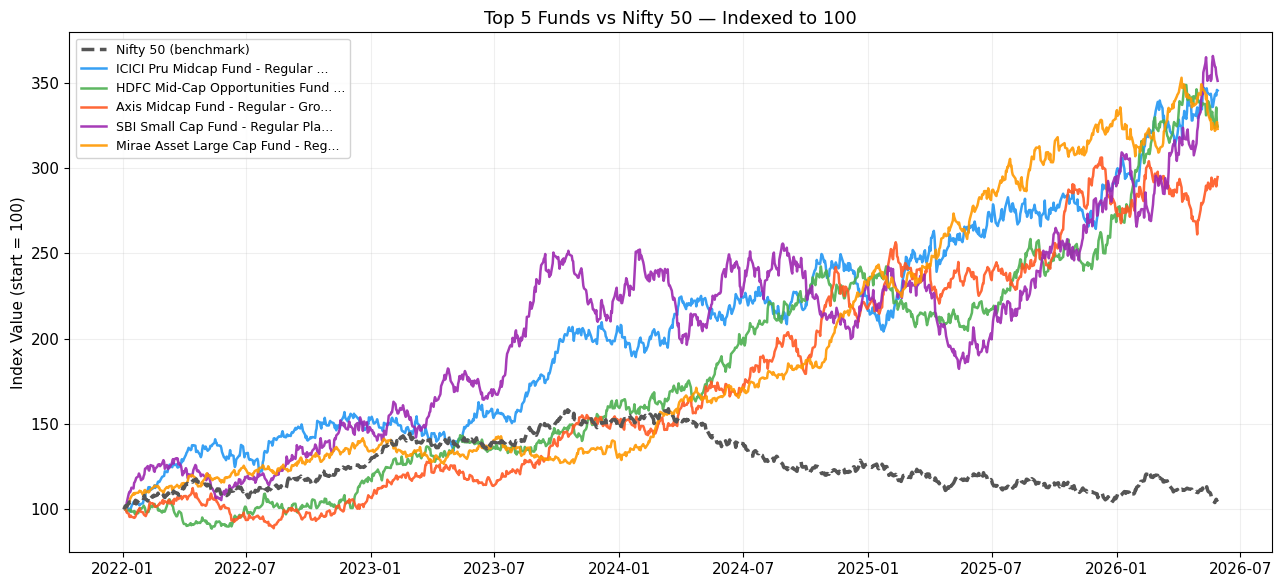

In [22]:
top5_codes = scorecard['amfi_code'].head(5).tolist()

fig, ax = plt.subplots(figsize=(13, 6))

# Nifty 50 benchmark (adjust column name)
bp = bench.sort_values('date')
bp = bench[bench['index_name'] == 'NIFTY50'].sort_values('date')
bi = bp['close_value'] / bp['close_value'].iloc[0] * 100
ax.plot(bp['date'], bi, color='#555', lw=2.5, ls='--',
        label='Nifty 50 (benchmark)', zorder=5)

colors = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800']
for i, code in enumerate(top5_codes):
    fd = nav[nav['amfi_code']==code].sort_values('date')
    ni = fd['nav'] / fd['nav'].iloc[0] * 100
    nm = fund[fund['amfi_code']==code]['scheme_name'].values[0]
    nm = nm[:32]+'...' if len(nm)>32 else nm
    ax.plot(fd['date'], ni, color=colors[i], lw=1.8, label=nm, alpha=0.9)

ax.set_title('Top 5 Funds vs Nifty 50 — Indexed to 100', fontsize=13)
ax.set_ylabel('Index Value (start = 100)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../data/processed/benchmark_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("\nTracking Error vs Nifty 100:\n")
for code in top5_codes:
    fr = nav[nav['amfi_code']==code][['date','daily_return']]
    mg = fr.merge(bench_ret, on='date', how='inner')
    te = (mg['daily_return'] - mg['nifty100_return']).std() * np.sqrt(252) * 100
    nm = fund[fund['amfi_code']==code]['scheme_name'].values[0][:35]
    print(f"  {nm:<35}  TE: {te:.2f}%")


Tracking Error vs Nifty 100:

  ICICI Pru Midcap Fund - Regular - G  TE: 23.20%
  HDFC Mid-Cap Opportunities Fund - R  TE: 22.88%
  Axis Midcap Fund - Regular - Growth  TE: 23.77%
  SBI Small Cap Fund - Regular Plan -  TE: 28.40%
  Mirae Asset Large Cap Fund - Regula  TE: 18.92%
